In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Load datasets
daily = pd.read_csv("../data/raw/dailyActivity_merged.csv")
hourly_steps = pd.read_csv("../data/raw/hourlySteps_merged.csv")
hourly_cal = pd.read_csv("../data/raw/hourlyCalories_merged.csv")
sleep_day = pd.read_csv("../data/raw/sleepDay_merged.csv")
minute_sleep = pd.read_csv("../data/raw/minuteSleep_merged.csv")
heart = pd.read_csv("../data/raw/heartrate_seconds_merged.csv")
weight = pd.read_csv("../data/raw/weightLogInfo_merged.csv")

In [13]:
# Convert dates
daily['ActivityDate'] = pd.to_datetime(daily['ActivityDate'])
hourly_steps['ActivityHour'] = pd.to_datetime(hourly_steps['ActivityHour'])
hourly_cal['ActivityHour'] = pd.to_datetime(hourly_cal['ActivityHour'])
sleep_day['SleepDay'] = pd.to_datetime(sleep_day['SleepDay'])

# Remove duplicates
daily.drop_duplicates(inplace=True)
sleep_day.drop_duplicates(inplace=True)

# Handle missing values
weight = weight.dropna(subset=['BMI'])

C:\Users\Dell\AppData\Local\Temp\ipykernel_4520\2418396159.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hourly_steps['ActivityHour'] = pd.to_datetime(hourly_steps['ActivityHour'])
C:\Users\Dell\AppData\Local\Temp\ipykernel_4520\2418396159.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  hourly_cal['ActivityHour'] = pd.to_datetime(hourly_cal['ActivityHour'])
C:\Users\Dell\AppData\Local\Temp\ipykernel_4520\2418396159.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  sleep_day['SleepDay'] = pd.to_datetime(sleep_day['SleepDay'])


## EDA

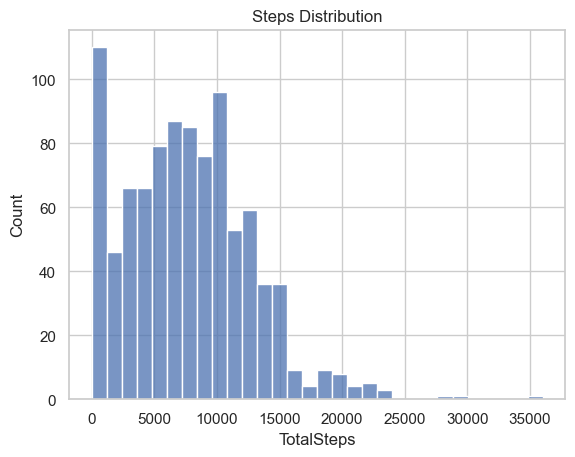

In [26]:
sns.histplot(daily['TotalSteps'], bins=30)
plt.title("Steps Distribution")
plt.show()

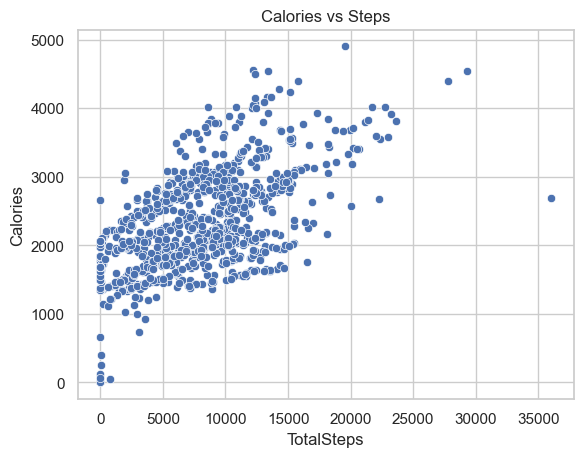

In [28]:
sns.scatterplot(x='TotalSteps', y='Calories', data=daily)
plt.title("Calories vs Steps")
plt.show()

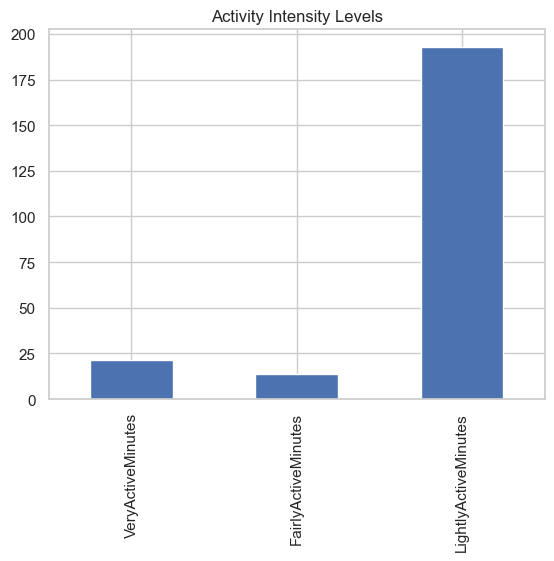

In [30]:
daily[['VeryActiveMinutes','FairlyActiveMinutes','LightlyActiveMinutes']].mean().plot(kind='bar')
plt.title("Activity Intensity Levels")
plt.show()

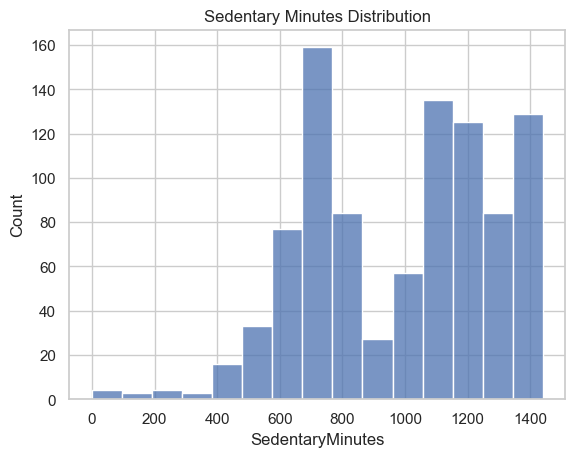

In [32]:
sns.histplot(daily['SedentaryMinutes'])
plt.title("Sedentary Minutes Distribution")
plt.show()

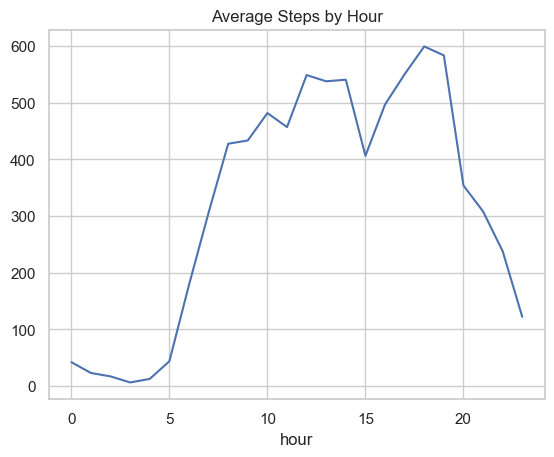

In [34]:
hourly_steps['hour'] = pd.to_datetime(hourly_steps['ActivityHour']).dt.hour
hourly_steps.groupby('hour')['StepTotal'].mean().plot()
plt.title("Average Steps by Hour")
plt.show()

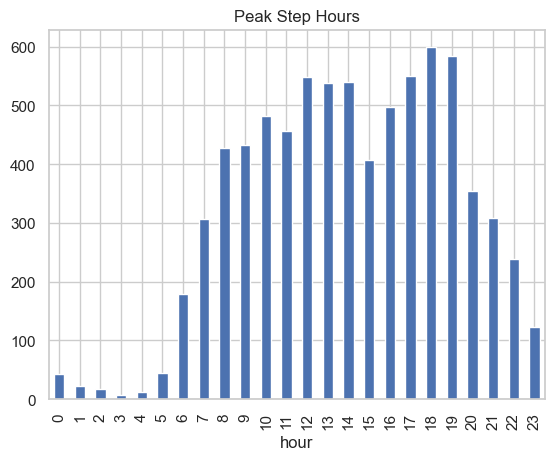

In [36]:
hourly_steps.groupby('hour')['StepTotal'].mean().plot(kind='bar')
plt.title("Peak Step Hours")
plt.show()

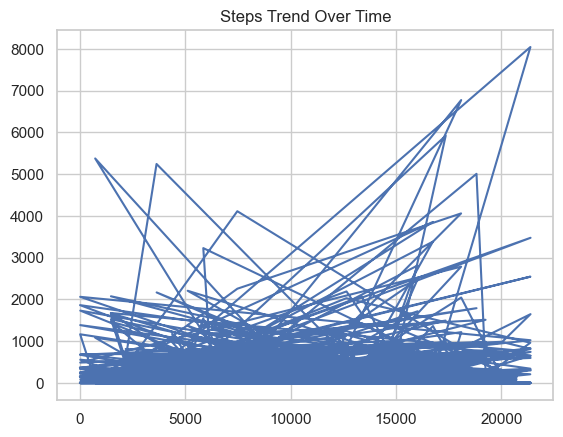

In [38]:
hourly_steps.sort_values('ActivityHour').head(1000)['StepTotal'].plot()
plt.title("Steps Trend Over Time")
plt.show()

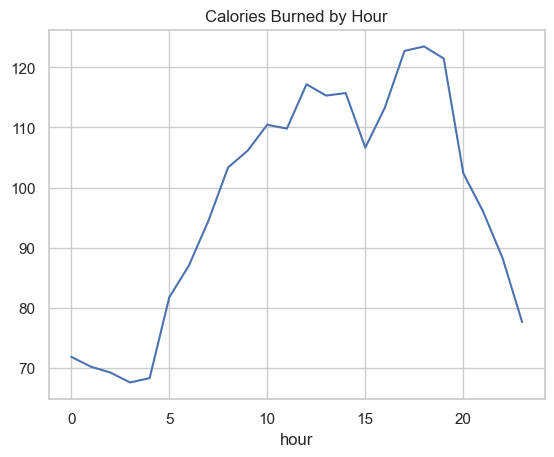

In [40]:
hourly_cal['hour'] = pd.to_datetime(hourly_cal['ActivityHour']).dt.hour
hourly_cal.groupby('hour')['Calories'].mean().plot()
plt.title("Calories Burned by Hour")
plt.show() 

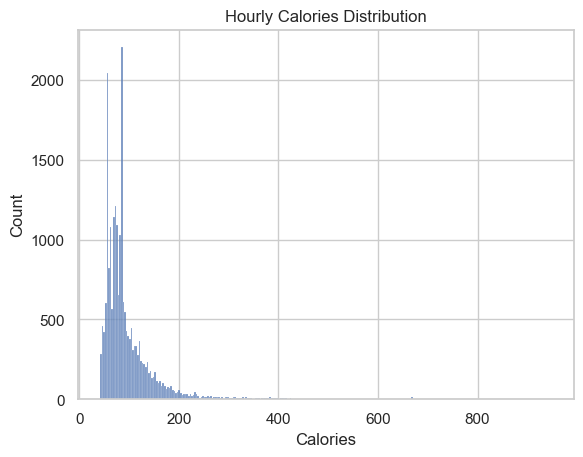

In [42]:
sns.histplot(hourly_cal['Calories'])
plt.title("Hourly Calories Distribution")
plt.show()

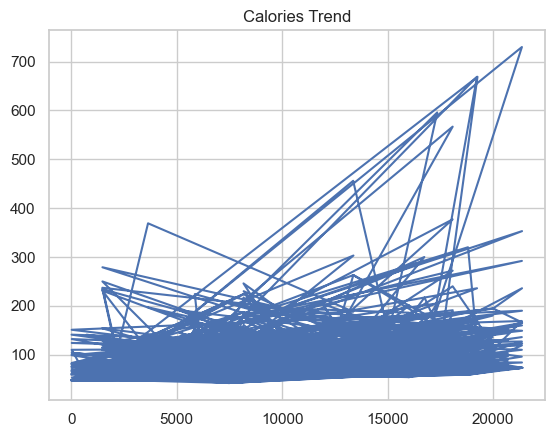

In [44]:
hourly_cal.sort_values('ActivityHour').head(1000)['Calories'].plot()
plt.title("Calories Trend")
plt.show()

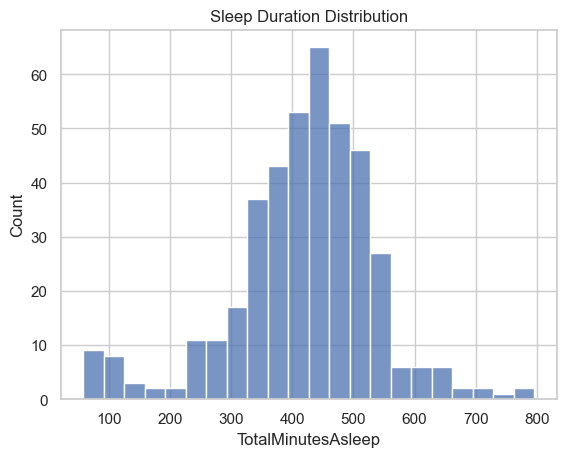

In [46]:
sns.histplot(sleep_day['TotalMinutesAsleep'])
plt.title("Sleep Duration Distribution")
plt.show()

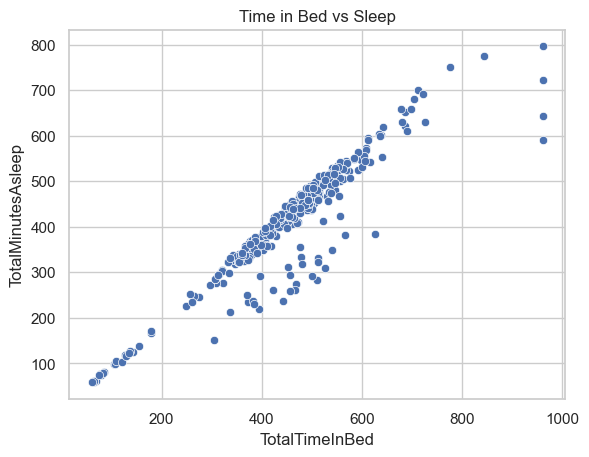

In [48]:
sns.scatterplot(x='TotalTimeInBed', y='TotalMinutesAsleep', data=sleep_day)
plt.title("Time in Bed vs Sleep")
plt.show()

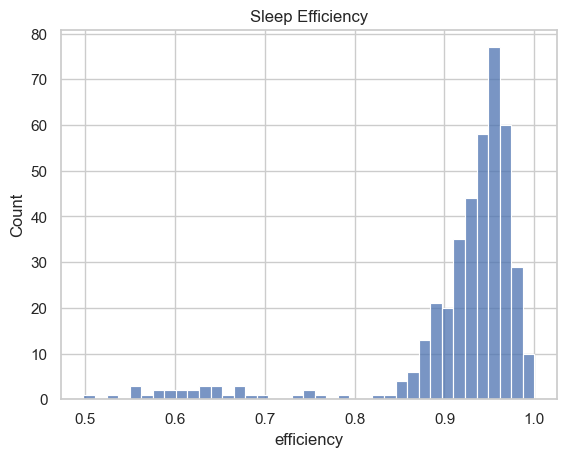

In [50]:
sleep_day['efficiency'] = sleep_day['TotalMinutesAsleep'] / sleep_day['TotalTimeInBed']
sns.histplot(sleep_day['efficiency'])
plt.title("Sleep Efficiency")
plt.show()

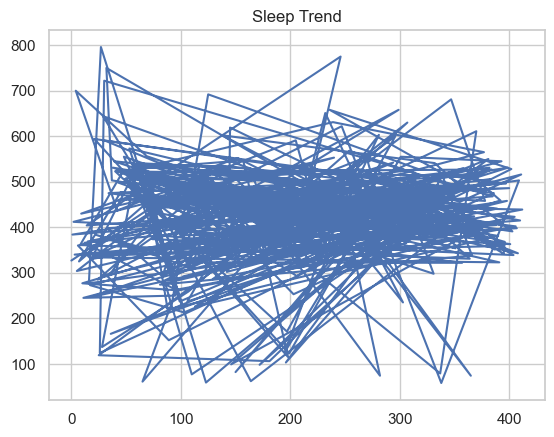

In [52]:
sleep_day.sort_values('SleepDay')['TotalMinutesAsleep'].plot()
plt.title("Sleep Trend")
plt.show()

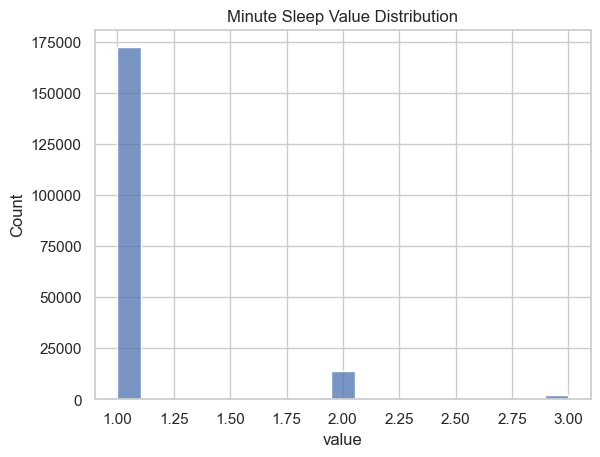

In [54]:
sns.histplot(minute_sleep['value'])
plt.title("Minute Sleep Value Distribution")
plt.show()

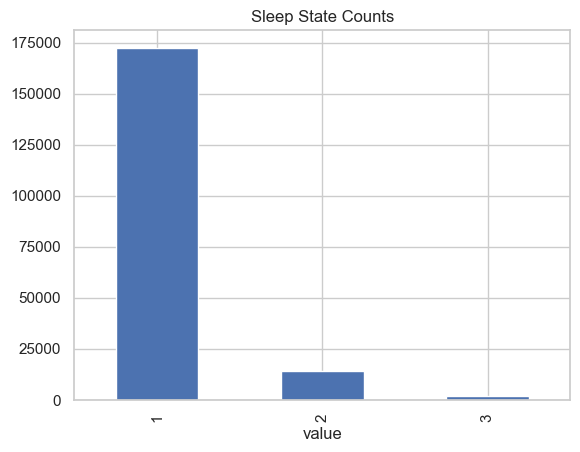

In [56]:
minute_sleep['value'].value_counts().plot(kind='bar')
plt.title("Sleep State Counts")
plt.show()

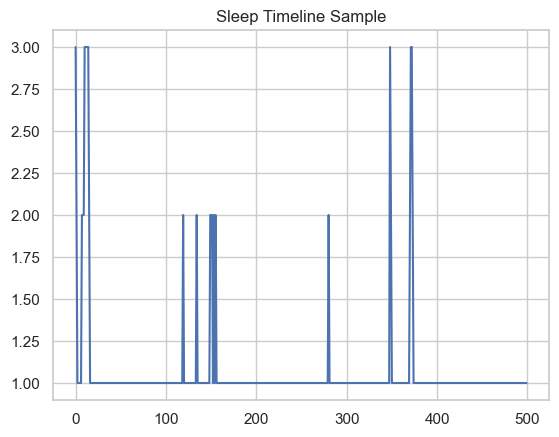

In [58]:
minute_sleep.head(500)['value'].plot()
plt.title("Sleep Timeline Sample")
plt.show()

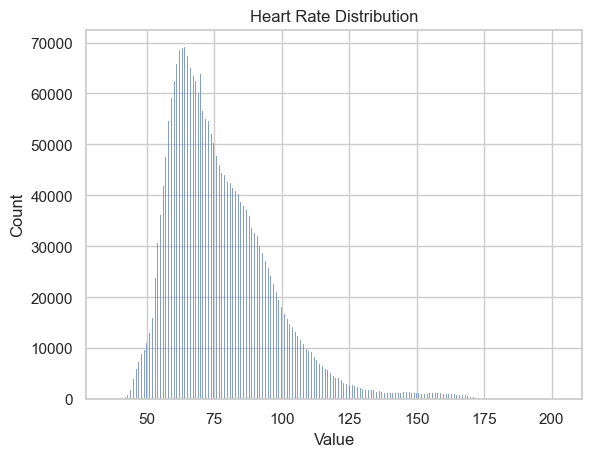

In [60]:
sns.histplot(heart['Value'])
plt.title("Heart Rate Distribution")
plt.show()

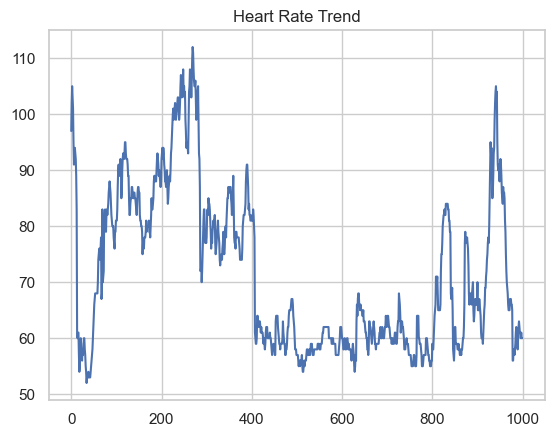

In [62]:
heart.head(1000)['Value'].plot()
plt.title("Heart Rate Trend")
plt.show()

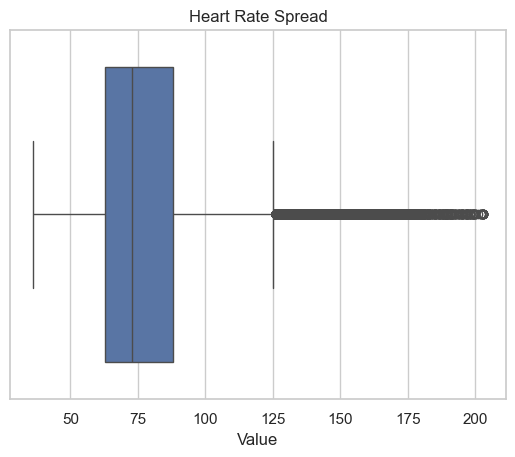

In [64]:
sns.boxplot(x=heart['Value'])
plt.title("Heart Rate Spread")
plt.show()

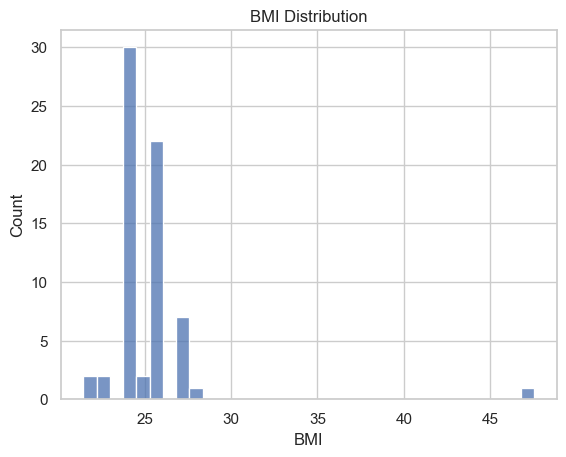

In [66]:
sns.histplot(weight['BMI'])
plt.title("BMI Distribution")
plt.show()

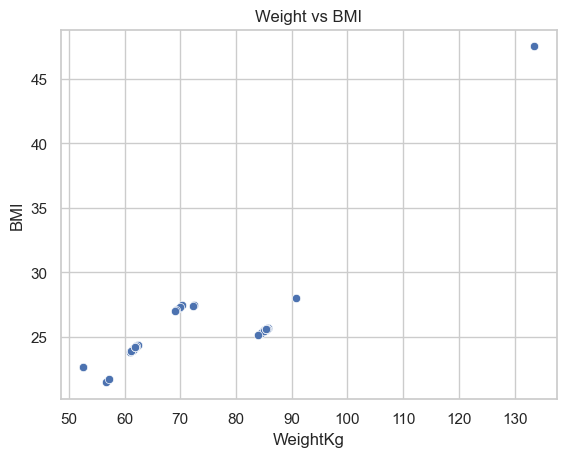

In [68]:
sns.scatterplot(x='WeightKg', y='BMI', data=weight)
plt.title("Weight vs BMI")
plt.show()

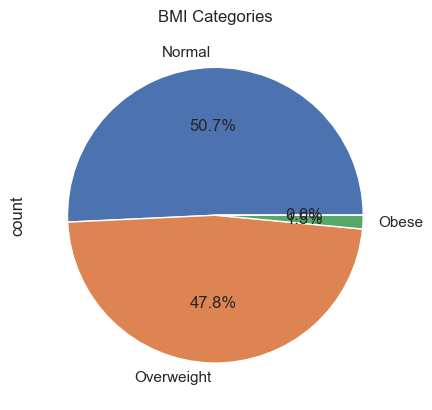

In [70]:
weight['BMI_category'] = pd.cut(weight['BMI'],
                               bins=[0,18.5,25,30,100],
                               labels=['Underweight','Normal','Overweight','Obese'])

weight['BMI_category'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("BMI Categories")
plt.show()

In [72]:
sleep_day['date'] = sleep_day['SleepDay'].dt.date
daily['date'] = daily['ActivityDate'].dt.date

In [74]:
merged = daily.merge(sleep_day[['Id','date','TotalMinutesAsleep']], on=['Id','date'], how='left')
merged = merged.merge(weight[['Id','BMI']], on='Id', how='left')

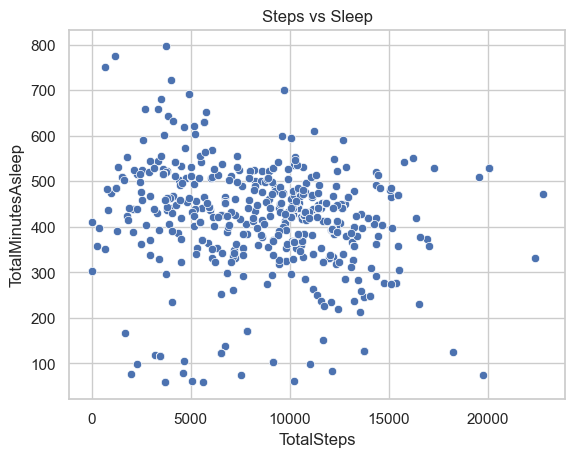

In [76]:
sns.scatterplot(x='TotalSteps', y='TotalMinutesAsleep', data=merged)
plt.title("Steps vs Sleep")
plt.show()

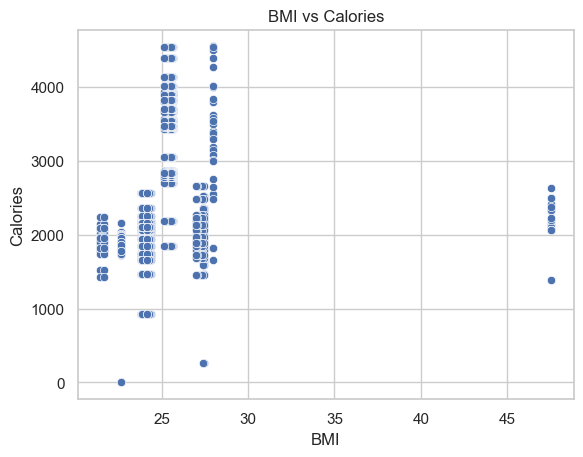

In [78]:
sns.scatterplot(x='BMI', y='Calories', data=merged)
plt.title("BMI vs Calories")
plt.show()

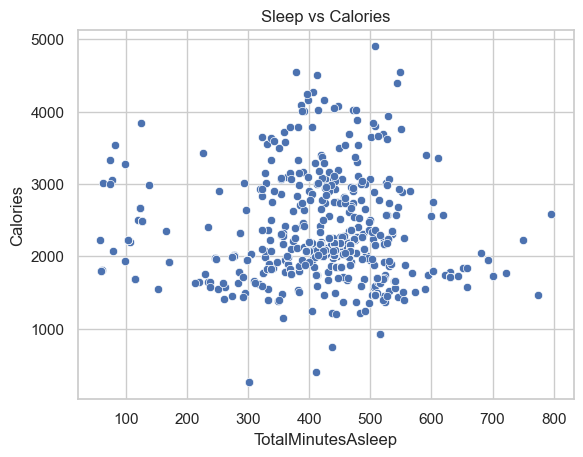

In [80]:
sns.scatterplot(x='TotalMinutesAsleep', y='Calories', data=merged)
plt.title("Sleep vs Calories")
plt.show()

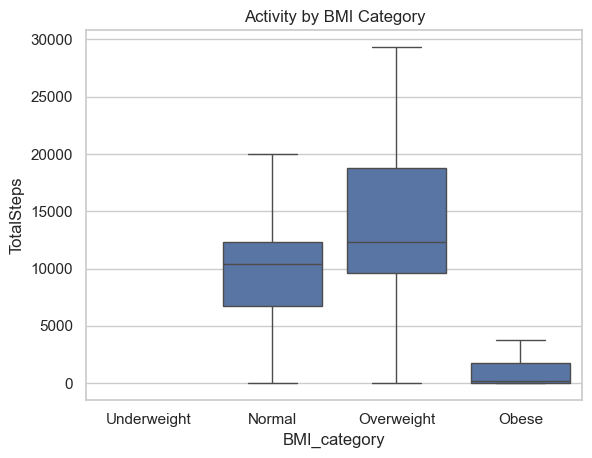

In [88]:
merged['BMI_category'] = pd.cut(
    merged['BMI'],
    bins=[0,18.5,25,30,100],
    labels=['Underweight','Normal','Overweight','Obese']
)
sns.boxplot(x='BMI_category', y='TotalSteps', data=merged)
plt.title("Activity by BMI Category")
plt.show()

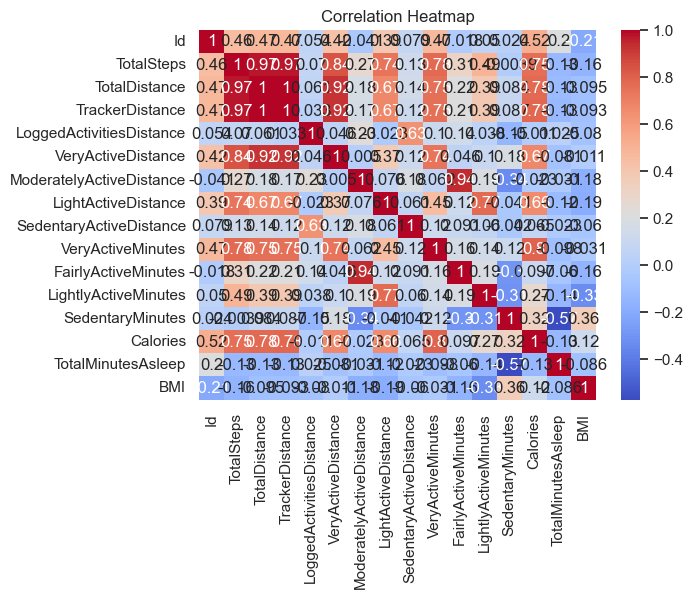

In [84]:
sns.heatmap(merged.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [92]:
# Normalize column names for PostgreSQL
daily.columns = daily.columns.str.lower()
daily.columns = daily.columns.str.replace(" ", "_")

sleep_day.columns = sleep_day.columns.str.lower()
weight.columns = weight.columns.str.lower()
merged.columns = merged.columns.str.lower()

In [94]:
# ================================
# SAVE CLEANED DATASETS
# ================================

import os

# Create folder if not exists
output_dir = "../data/cleaned"
os.makedirs(output_dir, exist_ok=True)

# ----------------
# 1. Daily Activity
# ----------------
daily_clean = daily.copy()
daily_clean.to_csv(f"{output_dir}/daily_activity_cleaned.csv", index=False)

# ----------------
# 2. Hourly Steps
# ----------------
hourly_steps_clean = hourly_steps.copy()
hourly_steps_clean.to_csv(f"{output_dir}/hourly_steps_cleaned.csv", index=False)

# ----------------
# 3. Hourly Calories
# ----------------
hourly_cal_clean = hourly_cal.copy()
hourly_cal_clean.to_csv(f"{output_dir}/hourly_calories_cleaned.csv", index=False)

# ----------------
# 4. Sleep Day
# ----------------
sleep_day_clean = sleep_day.copy()
sleep_day_clean.to_csv(f"{output_dir}/sleep_day_cleaned.csv", index=False)

# ----------------
# 5. Minute Sleep
# ----------------
minute_sleep_clean = minute_sleep.copy()
minute_sleep_clean.to_csv(f"{output_dir}/minute_sleep_cleaned.csv", index=False)

# ----------------
# 6. Heart Rate
# ----------------
heart_clean = heart.copy()
heart_clean.to_csv(f"{output_dir}/heartrate_cleaned.csv", index=False)

# ----------------
# 7. Weight / BMI
# ----------------
weight_clean = weight.copy()
weight_clean.to_csv(f"{output_dir}/weight_bmi_cleaned.csv", index=False)

# ----------------
# 8. Merged Dataset
# ----------------
merged = merged.drop_duplicates()
merged = merged.reset_index(drop=True)
merged_clean = merged.copy()
merged_clean.to_csv(f"{output_dir}/merged_fitness_data.csv", index=False)

print("✅ All cleaned datasets saved successfully in ../data/cleaned/")

✅ All cleaned datasets saved successfully in ../data/cleaned/
